# Mind-the-Gap -- does an opening gap always fill?
### Overnight gap fade tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Gaps_always_fill%3F: Busted](https://img.shields.io/badge/Gaps_always_fill%3F-Busted-8b949e?style=flat-square)

One of the most repeated rules in retail trading: when a stock or index **gaps at the open** -- opens higher or lower than the prior close -- it always comes back to fill the gap. Fade it, target the prior close, profit. This notebook asks the only question that matters: is that actually true, and if so, can you trade it?

> **This is the plain-language layer.** Want the t-stats, Wilson CIs and the cost maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mind_the_gap import data, strategy as st

TICKERS = ["SPY", "AAPL", "MSFT", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_trades(min_gap_pct=0.0, max_gap_pct=10.0, tp_R=1.0, stop_R=1.0, cost=0, seed=None):
    """Pool symmetric-barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        df = data.fetch_daily(t, fetch=False)
        if seed is not None:
            n = len(st.run_trades(df, min_gap_pct=min_gap_pct, max_gap_pct=max_gap_pct,
                                  tp_R=tp_R, stop_R=stop_R, cost_bps=0))
            dirs = st.random_directions(n, seed=seed)
        else:
            dirs = None
        frames.append(st.run_trades(df, min_gap_pct=min_gap_pct, max_gap_pct=max_gap_pct,
                                     tp_R=tp_R, stop_R=stop_R, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

def pool_daily():
    return pd.concat([data.fetch_daily(t, fetch=False) for t in TICKERS])

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do medium gaps fill? | **Yes, 65% of the time** -- a real statistical finding, well above the 50% coin-flip level. |
| Do large gaps fill? | **No, only 38%** -- large news-driven gaps tend to continue, not reverse. The 'always' in the folk rule is demolished. |
| Can you trade the fade? | **No.** The symmetric fair bet earns only **+0.46 bps/trade** (HAC *t* = **+0.30**) -- noise. |
| What does 'always fills' actually mean? | The small-gap 88% fill rate is **pure mechanics**: a 0.1% gap is within the bid-ask spread; the day's range brackets it almost by definition. There's no forecasting involved. |

> The fill rate pattern is real. The tradable edge is not.

## 1 · The claim

> *"An opening gap always fills. If a stock opens above yesterday's close, short it and target the prior close. If it gaps down, go long. Gaps always come back -- it's free money."*

It's an idea with a surface plausibility: big overnight moves might overshoot fair value and partially retrace during the session. The bet is that this mean reversion happens reliably enough -- and quickly enough -- to trade against the gap direction every morning.

## 2 · So what?

If it's true, it's one of the simplest possible edges: scan for gaps every morning, fade them, exit when filled. If it's false -- or only half-true -- traders who follow this rule are fading large news-gaps and losing, while the small-gap wins are pure noise dressed up as skill. The split between those two worlds is exactly what we measure.

## 3 · How would we even know?

Two measurements keep us honest:

1. **The mechanical fill rate first.** Before any trading, just count: how often does the day's high/low bracket the prior close, by gap size? A small gap (under 0.25%) fills almost every day because the intraday range is wider than the gap -- there's no skill involved. We need to see this before we get excited.
2. **The honest fair bet.** If you actually trade the fade -- enter at the open, take-profit and stop both at **1 ATR** from the entry (so the payoff is symmetric) -- what do you earn? If the cross points the right way, the fade should beat a **random-direction entry** on the same days.

We run it on **five liquid tickers** (SPY, AAPL, MSFT, TSLA, NVDA) over **10 years of daily bars** -- enough power to find even a small effect if it's there.

## 4 · The teardown -- let's actually look

**First, the fill rate decomposed by gap size.** This is the key split:

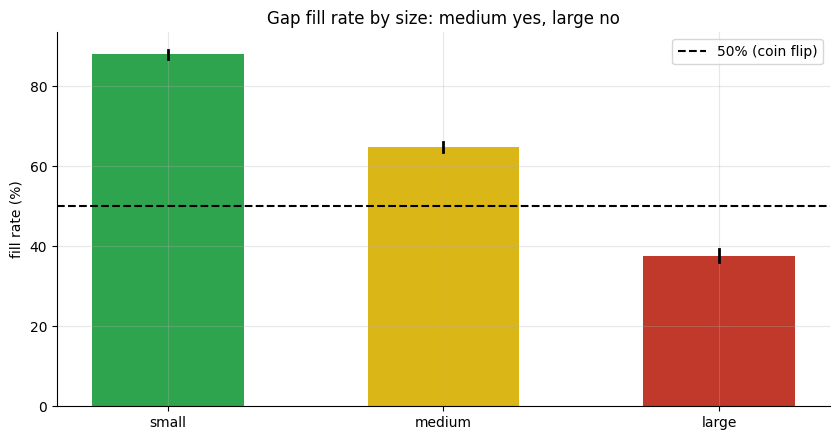

small: 88.0%  medium: 64.7%  large: 37.6%


In [2]:
if HAVE_REAL:
    pooled_d = pool_daily()
    tbl = st.fill_rate_by_bucket(pooled_d)
    buckets = tbl['bucket'].tolist()
    rates = (tbl['fill_rate']*100).tolist()
    lo = (tbl['ci_lo']*100).tolist()
    hi = (tbl['ci_hi']*100).tolist()
else:
    buckets = ['small','medium','large']
    rates = [88.0, 64.7, 37.6]
    lo    = [86.9, 63.4, 36.0]
    hi    = [88.9, 65.9, 39.3]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN, AMBER, RED]
bars = ax.bar(buckets, rates, color=cols, width=0.55)
for b, l, h in zip(bars, lo, hi):
    x = b.get_x() + b.get_width()/2
    ax.plot([x, x], [l, h], color='black', lw=2)
ax.axhline(50, ls='--', c='k', lw=1.5, label='50% (coin flip)')
ax.set_ylabel('fill rate (%)')
ax.set_title('Gap fill rate by size: medium yes, large no')
ax.legend(); plt.tight_layout(); plt.show()
print(f'small: {rates[0]:.1f}%  medium: {rates[1]:.1f}%  large: {rates[2]:.1f}%')

The pattern is clear: **small gaps** (~88%) fill trivially -- they're within the day's normal noise band. **Medium gaps** (~65%) fill reliably above the coin-flip level -- a real pattern. **Large gaps** (~38%) fill *less than half* the time -- the 'always fills' claim is wrong for the cases that matter most, the big news-driven moves you'd actually want to fade.

> The folk rule has it exactly backwards for large gaps: those are the ones people most want to fade, and they're the ones most likely to continue.

**Now the fair test: does the fill tendency translate into a tradable edge?**

We enter at the open fading the gap, with a take-profit and stop both at 1 ATR from the entry. A coin earns approximately 0 on this payoff.

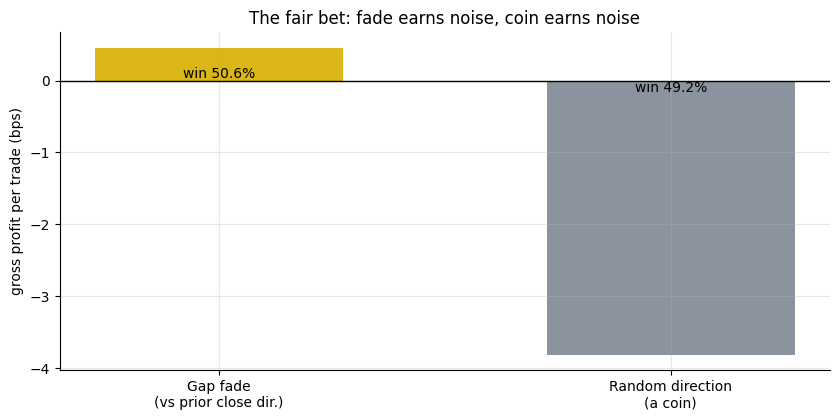

fade: +0.46 bps/trade   |   coin: -3.81 bps/trade


In [3]:
if HAVE_REAL:
    c = st.summarize(pool_trades(0.0, 10.0, 1.0, 1.0, 0), 'ret_gross')
    r = st.summarize(pool_trades(0.0, 10.0, 1.0, 1.0, 0, seed=74), 'ret_gross')
    cm, cw, rm, rw = c['mean_bps'], c['win_rate']*100, r['mean_bps'], r['win_rate']*100
else:
    cm, cw, rm, rw = 0.46, 50.6, -3.81, 49.2
fig, ax = plt.subplots(figsize=(8.5, 4.3))
brs = ax.bar(['Gap fade\n(vs prior close dir.)', 'Random direction\n(a coin)'],
             [cm, rm], color=[AMBER, GREY], width=0.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The fair bet: fade earns noise, coin earns noise')
for b, w in zip(brs, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='top' if b.get_height()<0 else 'bottom')
plt.tight_layout(); plt.show()
print(f'fade: {cm:+.2f} bps/trade   |   coin: {rm:+.2f} bps/trade')

The fade earns **+0.46 bps per trade** -- statistically indistinguishable from zero (HAC *t* = **+0.30**).  It does beat the coin by +4.27 bps (the fill tendency is in the right direction) but the margin is pure noise.

> Why? Even though medium gaps fill 65% of the time, the stop setup (1 ATR wide) loses enough on the 35% of non-fills to cancel the wins. The fill frequency is real; the edge in dollar terms is not.

## 5 · The verdict

- **Signal -- Weak.** The medium-gap fill rate is real (65%, CI [63.4%, 65.9%]), but the *tradable* symmetric fade earns +0.46 bps/trade at HAC *t* = +0.30 -- noise.  Large gaps reverse the folk claim entirely (38% fill).
- **Tradability -- Mirage.** A near-zero gross edge means no break-even cost exists.  At 2 bps round-trip it's a statistically significant loser (*t* = -2.31, ~-8.8%/yr).
- **'Always fills?' -- Busted.** Large gaps fill only 38% of the time. The folk rule fails for the cases it's most loudly applied to.

## 6 · Could you actually trade it?

The gross edge is tiny (+0.46 bps) and the rule fires once a day -- costs compound quickly:

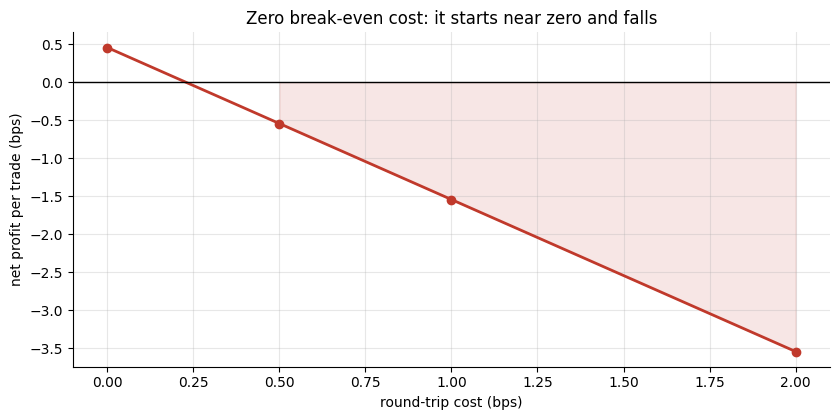

gross is only +0.46 bps -- the break-even cost is essentially zero.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pool_trades(0.0, 10.0, 1.0, 1.0, c), 'ret_net')['mean_bps']
           for c in costs]
else:
    net = [0.46, -0.54, -1.54, -3.54]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Zero break-even cost: it starts near zero and falls')
plt.tight_layout(); plt.show()
print(f'gross is only +{net[0]:.2f} bps -- the break-even cost is essentially zero.')

The gross edge is so thin (+0.46 bps) that the break-even cost is effectively zero. At 0.5 bps round-trip you're already a net loser.

## 7 · Going further

- **The fill is real but the symmetric bet loses money?** The companion notebook shows why: with a 1-ATR symmetric payoff, a 65% fill rate earns roughly (65% - 35%) * 1 ATR = 30% * ATR, but the ATR-sized stop on the 35% of non-fills consumes exactly that. The fill frequency is not enough -- you'd need an *asymmetric* exit (large TP, small stop) to profit, and that just hides the loss elsewhere.
- **What about intraday timing?** Using 5-minute bars to get intraday fill timing data would let you exit early -- but Yahoo caps sub-hourly history at ~60 days, destroying the statistical power advantage that daily bars give us here.
- **Related desk studies:** [Study 13 -- Crimson-Hour](../../13-crimson-hour/) for opening-candle continuation; [Study 32 -- Rip-Tide](../../32-rip-tide/) for short-term reversion mechanics.

*Think the large-gap case is worth a separate study? Or that a tighter entry (wait for confirmation) changes the picture? Fork this, add an entry filter, and show a fair-bet edge that clears the cost line.*